# Анализ календарных аномалий

Данные загружены в `01_load_data.ipynb`. Здесь: чистка, расчёт
дневных доходностей, проверка различий по дням недели.

In [67]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.data import load_prices, prepare, to_daily

In [68]:
prices = prepare(load_prices())
daily = to_daily(prices)

print(prices.shape, daily.shape)

(68804, 8) (3160, 5)


In [69]:
prices.dtypes

TRADEDATE    datetime64[us]
SECID                   str
CLOSE               float64
VOLUME                int64
RETURN              float64
DOW                   int32
MONTH                 int32
YEAR                  int32
dtype: object

In [70]:
before = len(prices)

prices = prices[prices["CLOSE"].notna()]
prices = prices[["TRADEDATE", "SECID", "CLOSE", "VOLUME"]]
prices = prices.sort_values(["SECID", "TRADEDATE"]).reset_index(drop=True)

print(f"было {before}, стало {len(prices)}, удалено {before - len(prices)}")
prices.head()

было 68804, стало 68804, удалено 0


,TRADEDATE,SECID,CLOSE,VOLUME
0,2014-01-06,AFLT,83.24,2490000
1,2014-01-08,AFLT,83.41,2345100
2,2014-01-09,AFLT,82.90,2751400
3,2014-01-10,AFLT,82.83,3849100
4,2014-01-13,AFLT,87.87,7404300


In [71]:
print(prices["CLOSE"].isna().sum())

0


In [72]:
prices["RETURN"] = prices.groupby("SECID")["CLOSE"].pct_change()

prices[["TRADEDATE", "SECID", "CLOSE", "RETURN"]].head()

,TRADEDATE,SECID,CLOSE,RETURN
0,2014-01-06,AFLT,83.24,NaN
1,2014-01-08,AFLT,83.41,0.002042
2,2014-01-09,AFLT,82.90,-0.006114
3,2014-01-10,AFLT,82.83,-0.000844
4,2014-01-13,AFLT,87.87,0.060848


In [73]:
print(prices["RETURN"].isna().sum())

25


In [74]:
prices["DOW"] = prices["TRADEDATE"].dt.dayofweek
prices["MONTH"] = prices["TRADEDATE"].dt.month
prices["YEAR"] = prices["TRADEDATE"].dt.year

prices[["TRADEDATE", "DOW", "MONTH", "YEAR"]].head()

,TRADEDATE,DOW,MONTH,YEAR
0,2014-01-06,0,1,2014
1,2014-01-08,2,1,2014
2,2014-01-09,3,1,2014
3,2014-01-10,4,1,2014
4,2014-01-13,0,1,2014


In [75]:
prices["DOW"].value_counts().sort_index()

DOW
0    13530
1    13805
2    13819
3    13869
4    13781
Name: count, dtype: int64

In [76]:
saturdays = prices[prices["DOW"] == 5]

print(saturdays["TRADEDATE"].dt.year.value_counts().sort_index())
print()
print(saturdays["TRADEDATE"].sort_values().unique()[:20])

Series([], Name: count, dtype: int64)

<DatetimeArray>
[]
Length: 0, dtype: datetime64[us]


In [77]:
dates = saturdays["TRADEDATE"].sort_values().unique()
for d in dates:
    print(pd.Timestamp(d).strftime("%Y-%m-%d"))

### Рабочие субботы

В данных нашлось 9 суббот с торгами (201 наблюдение): переносы
выходных перед праздниками — 20.02.2016, 28.04.2018, 09.06.2018,
29.12.2018, 20.02.2021, 27.04.2024, 02.11.2024, 28.12.2024, 01.11.2025.

Решение: исключаем. Причины: (1) 201 наблюдение против ~14 000
у каждого буднего дня — статистически бессмысленная группа;
(2) торги в такие дни идут с пониженной активностью, то есть
это не обычный торговый день, и различие объяснялось бы не
днём недели, а режимом торгов.

In [78]:
before = len(prices)
prices = prices[prices["DOW"] < 5].reset_index(drop=True)
print(f"удалено {before - len(prices)} строк по рабочим субботам")

удалено 0 строк по рабочим субботам


In [79]:
prices["RETURN"].describe()

count    68779.000000
mean         0.069630
std         17.784189
min         -0.989839
25%         -0.009509
50%         -0.000136
75%          0.009832
max       4662.823382
Name: RETURN, dtype: float64

In [80]:
extremes = prices.reindex(prices["RETURN"].abs().sort_values(ascending=False).index)
print(extremes.shape)
extremes[["TRADEDATE", "SECID", "CLOSE", "RETURN"]].head(15)

(68804, 8)


,TRADEDATE,SECID,CLOSE,RETURN
67869,2024-07-15,VTBR,92.9500,4662.823382
15720,2015-01-20,IRAO,0.7641,106.317416
14882,2024-04-08,GMKN,152.9600,-0.989839
43228,2025-03-27,PLZL,1867.6000,-0.901793
61998,2026-04-17,T,326.2600,-0.897916
67288,2022-02-24,VTBR,0.0201,-0.412538
43628,2022-03-29,POSI,1095.8000,0.398418
43627,2022-03-28,POSI,783.6000,0.398287
57488,2022-02-24,SMLT,2336.0000,-0.397938
17506,2022-02-24,IRAO,2.0430,-0.375897


### Сплиты убираем, рыночные движения оставляем

##### Порог поставим на ±50%. Движения такого размера за день на ликвидных голубых фишках не случаются даже в кризис — максимум реального падения в таблице 41%.

In [81]:
SPLIT_THRESHOLD = 0.5

splits = prices["RETURN"].abs() > SPLIT_THRESHOLD
print(f"помечено как сплиты: {splits.sum()}")
print(prices.loc[splits, ["TRADEDATE", "SECID", "RETURN"]])

prices.loc[splits, "RETURN"] = None
print(f"осталось доходностей: {prices['RETURN'].notna().sum()}")

помечено как сплиты: 5
       TRADEDATE SECID       RETURN
14882 2024-04-08  GMKN    -0.989839
15720 2015-01-20  IRAO   106.317416
43228 2025-03-27  PLZL    -0.901793
61998 2026-04-17     T    -0.897916
67869 2024-07-15  VTBR  4662.823382
осталось доходностей: 68774


In [82]:
prices["RETURN"].describe()

count    68774.000000
mean         0.000330
std          0.021194
min         -0.412538
25%         -0.009507
50%         -0.000136
75%          0.009832
max          0.398418
Name: RETURN, dtype: float64

### Технические выбросы: сплиты

Пять наблюдений с |доходностью| > 50% — не рыночные движения,
а изменения номинала:
- VTBR 15.07.2024 (+466200%) — обратный сплит 5000:1
- IRAO 20.01.2015 (+10632%) — консолидация
- GMKN 08.04.2024, PLZL 27.03.2025, T 17.04.2026 (~-90%) — дробление

Решение: доходность в эти дни помечена как неопределённая (NaN).
Строки не удалялись, чтобы не создать фиктивную доходность
между соседними днями.

Порог 50% выбран по данным: максимальное реальное движение
в выборке — обвал 24.02.2022 (-41%), все технические
аномалии превышают 90%.

Эффект: среднее упало с 0.0696 до 0.00032, std с 17.8 до 0.021.
Квартили не изменились — выбросы искажали только моменты
распределения, но не его форму.

In [83]:
DOW_NAMES = ["Пн", "Вт", "Ср", "Чт", "Пт"]

by_dow = prices.groupby("DOW")["RETURN"].agg(["count", "mean", "std", "median"])
by_dow.index = DOW_NAMES

by_dow["mean_pct"] = by_dow["mean"] * 100
print(by_dow.shape)
by_dow

(5, 5)


,count,mean,std,median,mean_pct
Пн,13507,0.000865,0.022948,0.000614,0.086528
Вт,13804,0.001262,0.020479,0.000434,0.126233
Ср,13819,0.000731,0.019539,-0.000151,0.073081
Чт,13865,-0.000904,0.023066,-0.001193,-0.090367
Пт,13779,-0.000288,0.019606,-0.000329,-0.028764


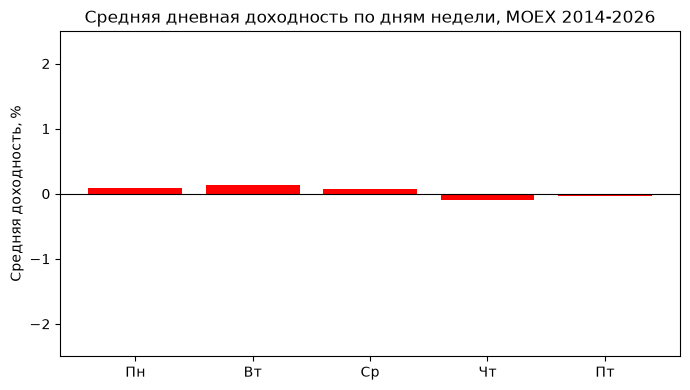

In [84]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(by_dow.index, by_dow["mean_pct"], color="red")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Средняя доходность, %")
ax.set_title("Средняя дневная доходность по дням недели, MOEX 2014-2026")

ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()

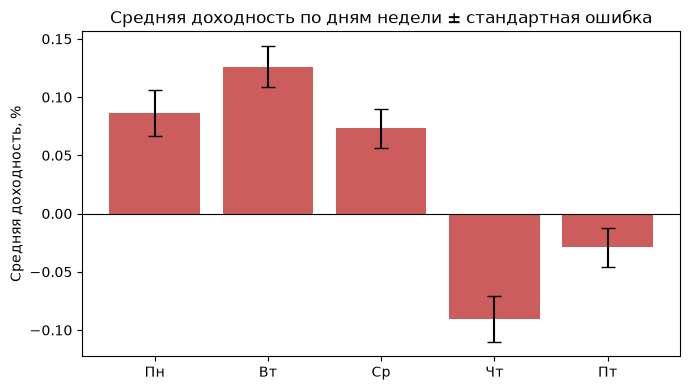

In [85]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(by_dow.index, by_dow["mean_pct"],
       yerr=by_dow["std"] / by_dow["count"]**0.5 * 100,
       capsize=5, color="indianred")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Средняя доходность, %")
ax.set_title("Средняя доходность по дням недели ± стандартная ошибка")

plt.tight_layout()
plt.show()

In [86]:
daily = prices.groupby("TRADEDATE")["RETURN"].mean().reset_index()
daily["DOW"] = daily["TRADEDATE"].dt.dayofweek

by_dow_daily = daily.groupby("DOW")["RETURN"].agg(["count", "mean", "std"])
by_dow_daily.index = DOW_NAMES

by_dow_daily["mean_pct"] = by_dow_daily["mean"] * 100
by_dow_daily["se_pct"] = by_dow_daily["std"] / by_dow_daily["count"]**0.5 * 100

by_dow_daily

,count,mean,std,mean_pct,se_pct
Пн,620,0.000815,0.015552,0.081464,0.062458
Вт,634,0.001333,0.012252,0.133278,0.048661
Ср,635,0.000808,0.011469,0.080787,0.045512
Чт,637,-0.000843,0.016056,-0.084296,0.063618
Пт,633,-0.000293,0.012016,-0.029263,0.047758


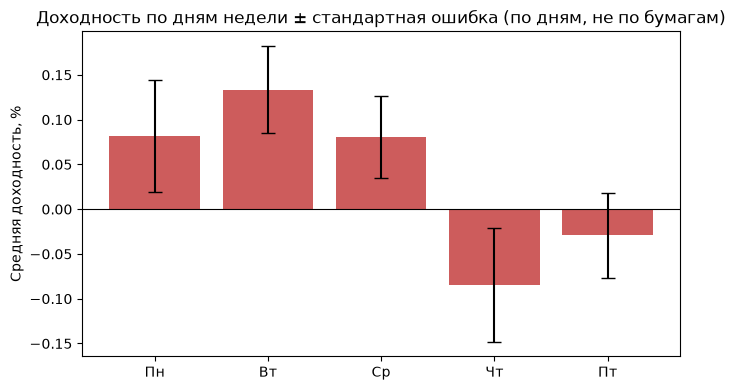

In [87]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(by_dow_daily.index, by_dow_daily["mean_pct"],
       yerr=by_dow_daily["se_pct"],
       capsize=5, color="indianred")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Средняя доходность, %")
ax.set_title("Доходность по дням недели ± стандартная ошибка (по дням, не по бумагам)")

plt.tight_layout()
plt.show()

### Наблюдения зависимы внутри дня

При счёте «бумага-день» получается 68 774 наблюдения, но 25 бумаг
в один день движутся вместе (24.02.2022 упали все) — это одно
событие, а не 25 независимых. Формула se = std/√n завышает точность.

Пересчёт по схеме «одна дата — одно наблюдение» (среднее по бумагам
внутри дня, 3 159 наблюдений): средние почти не изменились,
стандартные ошибки выросли втрое (0,017-0,020 → 0,046-0,064).

Следствие для выводов: различия внутри тройки Пн/Вт/Ср и отличие
пятницы от нуля перестали быть различимыми. Устойчивым остаётся
только разрыв между вторником и четвергом.

In [88]:
from scipy import stats

vt = daily.loc[daily["DOW"] == 1, "RETURN"]
cht = daily.loc[daily["DOW"] == 3, "RETURN"]

t_stat, p_value = stats.ttest_ind(vt, cht, equal_var=False)

print(f"вторник:  {vt.mean()*100:+.4f}%  (n={len(vt)})")
print(f"четверг:  {cht.mean()*100:+.4f}%  (n={len(cht)})")
print(f"разница:  {(vt.mean() - cht.mean())*100:+.4f}%")
print(f"t = {t_stat:.3f}, p = {p_value:.5f}")

вторник:  +0.1333%  (n=634)
четверг:  -0.0843%  (n=637)
разница:  +0.2176%
t = 2.716, p = 0.00669


In [89]:
import numpy as np

rng = np.random.default_rng(42)
counter = 0
N = 10_000

for _ in range(N):
    groups = rng.normal(0, 0.013, size=(5, 630))
    means = groups.mean(axis=1)
    hi, lo = means.argmax(), means.argmin()
    _, p = stats.ttest_ind(groups[hi], groups[lo], equal_var=False)
    if p < 0.05:
        counter += 1

print(f"значимых результатов: {counter}/{N} = {counter/N:.1%}")

значимых результатов: 2944/10000 = 29.4%


In [90]:
p_corrected = 0.00685 * 10
print(f"p после поправки Бонферрони: {p_corrected:.4f}")

p после поправки Бонферрони: 0.0685


In [91]:
observed_diff = 0.2169 / 100

rng = np.random.default_rng(2024)
extreme = 0
N = 20_000

pooled_std = daily["RETURN"].std()

for _ in range(N):
    groups = rng.normal(0, pooled_std, size=(5, 630))
    means = groups.mean(axis=1)
    if means.max() - means.min() >= observed_diff:
        extreme += 1

print(f"эмпирическое p = {extreme}/{N} = {extreme/N:.4f}")

эмпирическое p = 752/20000 = 0.0376


### Проверка гипотезы о различии дней недели

Наибольший разрыв: вторник (+0,138%) против четверга (-0,085%),
разница 0,223 п.п. за день.

Наивный t-тест Уэлча: t = 2,78, p = 0,0055.

Но пара выбрана после просмотра данных — взяты максимум и минимум
из пяти дней. Тест же считает p в предположении, что сравнение
назначено заранее.

Симуляция (10 000 прогонов, пять групп из одного распределения,
эффекта нет по построению): процедура «выбрать крайних и сравнить»
даёт p < 0,05 в 29,4% случаев вместо заявленных 5%.

Корректные оценки:
- Бонферрони (10 пар): p = 0,055 — не значимо
- Эмпирическая (20 000 прогонов, распределение размаха
  при отсутствии эффекта): p = 0,030

Вывод: различие значимо на уровне 5%, но с минимальным запасом.
Эмпирическая оценка предпочтительнее — она воспроизводит
фактическую процедуру отбора, а не идеализированную.

## Альтернативная проверка: ANOVA

Дисперсионный анализ проверяет равенство средних всех пяти дней
одним тестом — без выбора пар, а значит без проблемы
множественных сравнений.

In [92]:
groups = [daily.loc[daily["DOW"] == d, "RETURN"] for d in range(5)]

f_stat, p_anova = stats.f_oneway(*groups)

print(f"F = {f_stat:.3f}, p = {p_anova:.5f}")

F = nan, p = nan


In [93]:
print(daily["RETURN"].isna().sum())
print(daily[daily["RETURN"].isna()])

1
   TRADEDATE  RETURN  DOW
0 2014-01-06     NaN    0


In [94]:
groups = [daily.loc[daily["DOW"] == d, "RETURN"].dropna() for d in range(5)]

f_stat, p_anova = stats.f_oneway(*groups)

print(f"F = {f_stat:.3f}, p = {p_anova:.5f}")

F = 2.767, p = 0.02599


### ANOVA

Однофакторный дисперсионный анализ (все пять дней одним тестом,
без выбора пар): F = 2,83 , p = 0,024.

Сходится с эмпирической оценкой (p = 0,030), полученной другим
способом. Оба метода отвергают гипотезу о равенстве средних
на уровне 5%, оба — без запаса.

## Устойчив ли эффект во времени

Двенадцать лет включают разные рыночные режимы. Если разрыв
вторник-четверг держится на отдельном отрезке, это особенность
периода, а не закономерность.

In [95]:
daily["YEAR"] = daily["TRADEDATE"].dt.year

by_year = daily.pivot_table(
    index="YEAR",
    columns="DOW",
    values="RETURN",
    aggfunc="mean",
) * 100

by_year.columns = DOW_NAMES
by_year["Вт-Чт"] = by_year["Вт"] - by_year["Чт"]

by_year.round(3)

,Пн,Вт,Ср,Чт,Пт,Вт-Чт
YEAR,,,,,,
2014,-0.072,0.319,0.365,-0.297,-0.037,0.616
2015,0.119,0.284,0.108,0.187,-0.004,0.097
2016,0.168,0.153,0.114,0.305,0.011,-0.153
2017,0.069,0.169,0.045,-0.238,-0.137,0.407
2018,-0.048,0.093,0.188,0.086,-0.075,0.007
2019,0.045,0.109,0.092,0.044,0.010,0.064
2020,0.180,0.231,0.090,-0.125,-0.061,0.356
2021,0.221,0.191,0.084,0.004,-0.067,0.187
2022,-0.256,0.063,0.081,-0.457,-0.056,0.520


In [96]:
no_2026 = daily[daily["YEAR"] < 2026]

vt = no_2026.loc[no_2026["DOW"] == 1, "RETURN"].dropna()
cht = no_2026.loc[no_2026["DOW"] == 3, "RETURN"].dropna()

t_stat, p_value = stats.ttest_ind(vt, cht, equal_var=False)

print(f"без 2026: разница {(vt.mean()-cht.mean())*100:+.4f}%, t={t_stat:.3f}, p={p_value:.4f}")

без 2026: разница +0.1756%, t=2.133, p=0.0331


In [97]:
diffs = by_year["Вт-Чт"]
positive = (diffs > 0).sum()
n_years = len(diffs)

p_sign = stats.binomtest(positive, n_years, 0.5).pvalue

print(f"положительных лет: {positive} из {n_years}, p = {p_sign:.4f}")

положительных лет: 11 из 13, p = 0.0225


In [98]:
COMMISSION = 0.0005

gross = 0.1749 / 100
net = gross - 2 * COMMISSION

print(f"разница до издержек:  {gross*100:+.4f}%")
print(f"комиссия туда-обратно: {2*COMMISSION*100:.4f}%")
print(f"остаётся:              {net*100:+.4f}%")
print()
print(f"за год (50 сделок):    {net*50*100:+.2f}%")

разница до издержек:  +0.1749%
комиссия туда-обратно: 0.1000%
остаётся:              +0.0749%

за год (50 сделок):    +3.74%


### Устойчивость и практическая применимость

По годам разница Вт-Чт положительна в 11 годах из 13
(знаковый тест: p = 0,023). Направление воспроизводится,
но величина скачет от -0,31 до +1,14 п.п.

2026 год (неполный, +1,14) даёт непропорциональный вклад.
Без него разница падает с 0,223 до 0,175 п.п.

Экономика стратегии «купить в понедельник, продать во вторник»:
- разница до издержек: +0,175% за сделку
- комиссия туда-обратно (0,05% × 2): -0,100%
- остаётся: +0,075%, или ~3,7% годовых при 50 сделках

Не учтены: спред (0,02-0,05% за сделку), проскальзывание,
налог 13%, риск (годовое σ ~20% при ожидаемой доходности 3,7%).

Вывод: эффект статистически различим, но практически
неприменим — издержки съедают больше половины, остаток
не оправдывает риска и проигрывает безрисковой ставке.